# Как визуализировать данные

## План урока

* Почему важно визуализировать данные?
* Что такое хорошая визуализация?
* Практика в jupyter notebook: библиотеки Seaborn, Matplotlb, Plotly.

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px

## Квартет Энскомба

In [2]:
data_1 = pd.read_csv('anscombe_1.csv')
data_2 = pd.read_csv('anscombe_2.csv')
data_3 = pd.read_csv('anscombe_3.csv')
data_4 = pd.read_csv('anscombe_4.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'anscombe_1.csv'

In [ ]:
data_1

In [ ]:
print(data_1.describe())
print(data_2.describe())
print(data_3.describe())
print(data_4.describe())

In [ ]:
figure, ax = plt.subplots(2, 2)

In [ ]:
plt.rcParams['figure.figsize'] = (10, 7)

In [ ]:
figure, ax = plt.subplots(2, 2)

data_1.plot(x='x', y='y', ax=ax[0, 0], kind='scatter')
data_2.plot(x='x', y='y', ax=ax[0, 1], kind='scatter')
data_3.plot(x='x', y='y', ax=ax[1, 0], kind='scatter')
data_4.plot(x='x', y='y', ax=ax[1, 1], kind='scatter')

---
Если таблицы дают нам точность данных, а статистика — описание тенденций набора данных, то визуализация позволяет увидеть закономерности и приблизиться к природе данных.

---
### Зачем визуализировать данные?
- Увидеть закономерности и разобраться в природе данных, затрачивая при этом минимальное количество усилий.
- Наглядно продемонстрировать результаты экспериментов или инсайты в данных.

### Из чего состоит хорошая визуализация?
- Оси и шкалы задают размерность визуализации и определяют ее внешний вид.
- Заголовок и подписи данных добавляют контекст: на что смотрим и в каких единицах измерения.
- Визуальная кодировка — непосредственное наполнение диаграммы.

In [ ]:
data = pd.DataFrame({
    'shop_1': [20, 24, 10, 5, 12, 19],
    'shop_2': [30, 14, 6, 18, 20, 12],
})

In [ ]:
plt.plot(data.shop_1, label='shop_1')
plt.plot(data.shop_2, label='shop_2')

plt.legend()
plt.xlabel('День недели')
plt.ylabel('Число продаж')

plt.title('Продажи в магазинах')

## Боевой датасет

---
Наш знакомый ювелир за 5 лет своей работы записывал в табличку характеристики бриллиантов, которые попадали к нему в руки. Его опыт позволяет замечать многие закономерности в данных, однако он обратился к нам за помощью.

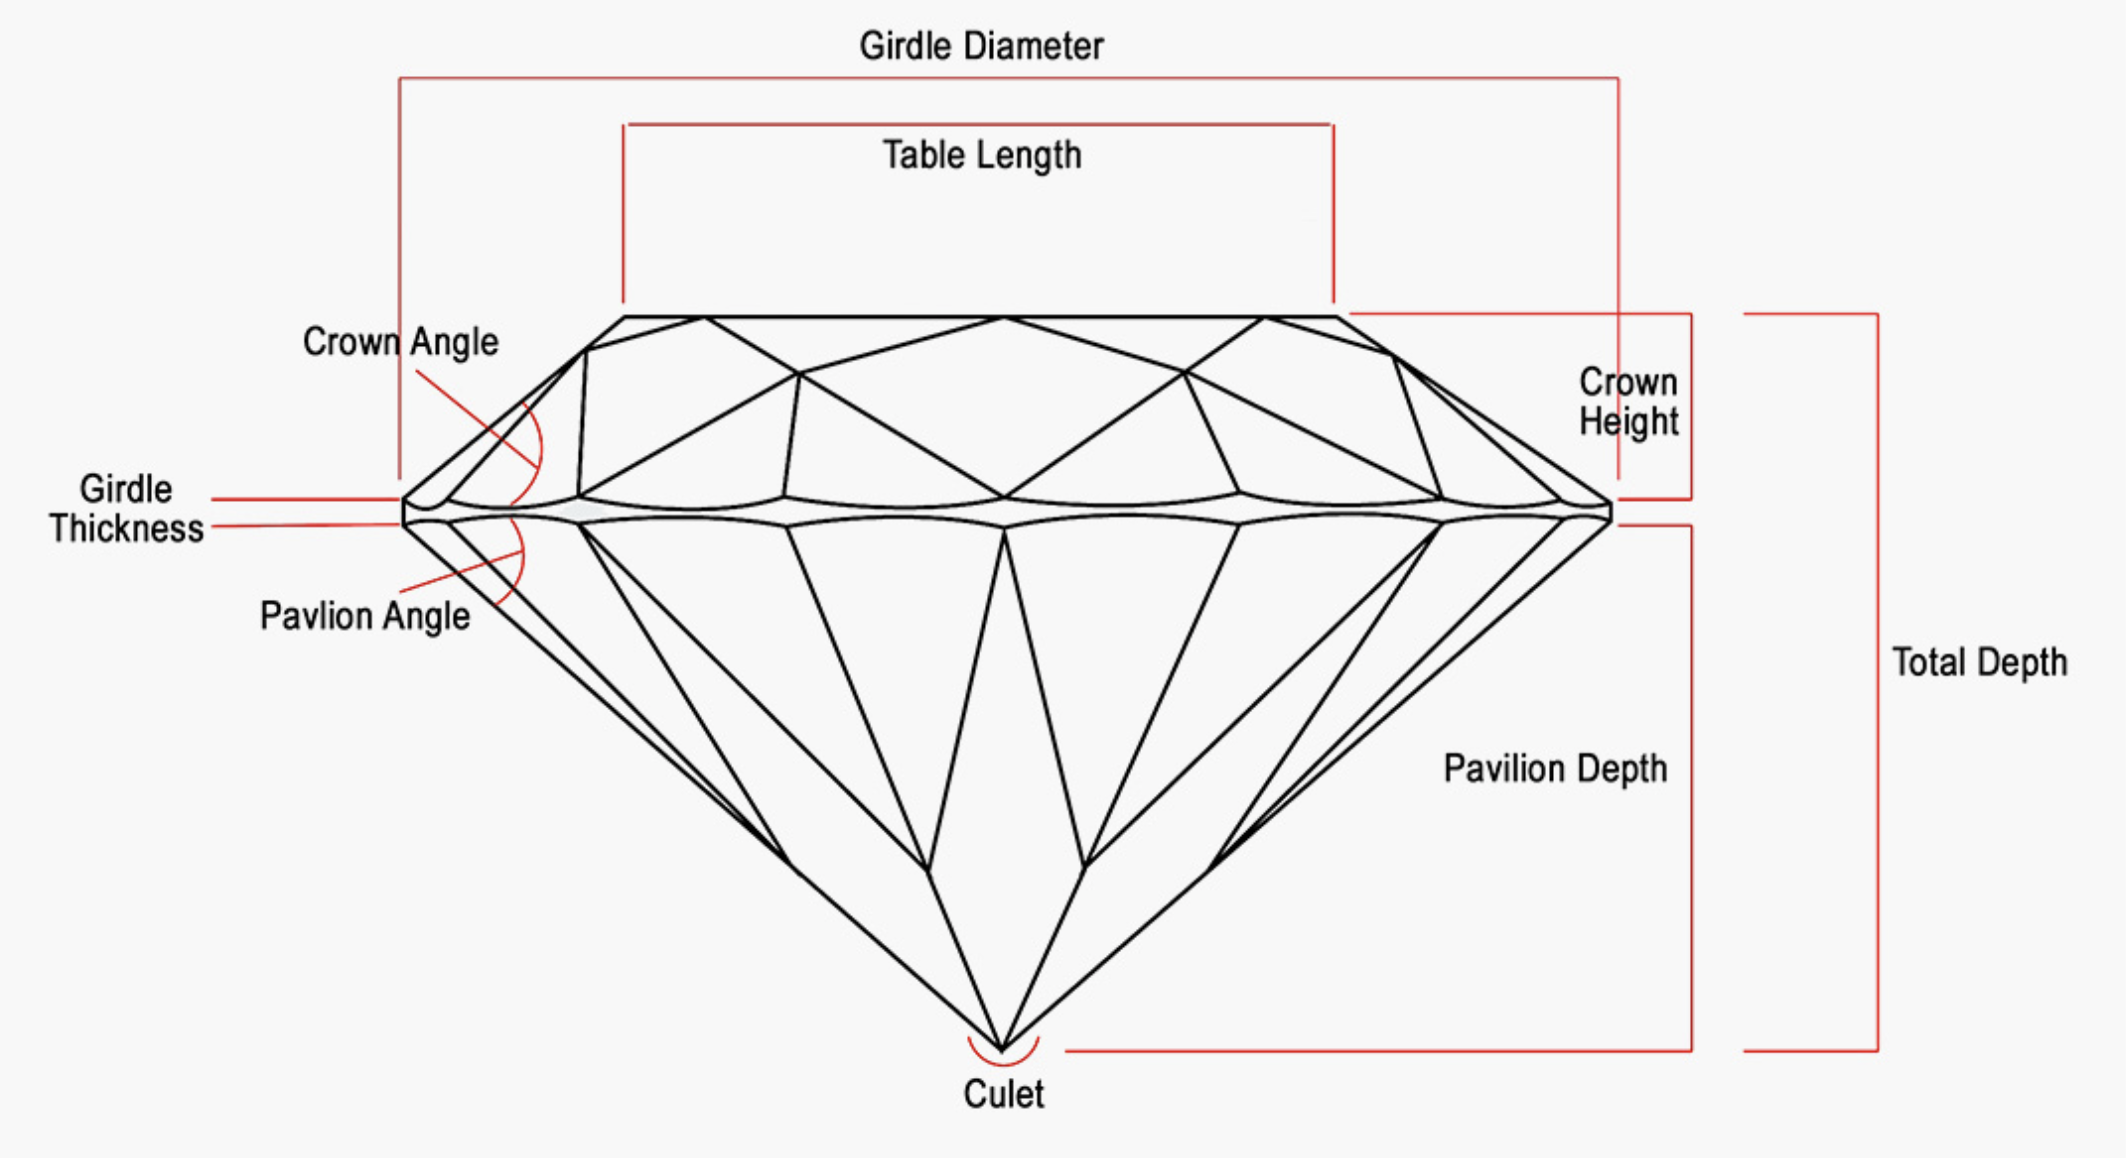</img>

In [4]:
data = pd.read_csv('Diamonds Prices2022.csv', index_col=0)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53943 entries, 1 to 53943
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53943 non-null  float64
 1   cut      53943 non-null  str    
 2   color    53943 non-null  str    
 3   clarity  53943 non-null  str    
 4   depth    53943 non-null  float64
 5   table    53943 non-null  float64
 6   price    53943 non-null  int64  
 7   x        53943 non-null  float64
 8   y        53943 non-null  float64
 9   z        53943 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


In [6]:
data = data[:5000]

**Что нужно сделать:**
1. Выяснить, от чего больше всего зависит вес бриллианта в каратах и меняется ли эта зависимость от типа огранки.
2. Понять, как распределены значения глубины среди бриллиантов в датасете, и  определить, есть ли доминирующие диапазоны глубины.
3. Выяснить, каким образом распределены веса бриллиантов в каратах в наборе данных. Есть ли среди них выбросы? Существуют ли статистически значимые различия в весе между группами с разной огранкой?
4. Описать набор данных и ответить на вопрос: какой цвет и огранка преобладают?

## Seaborn

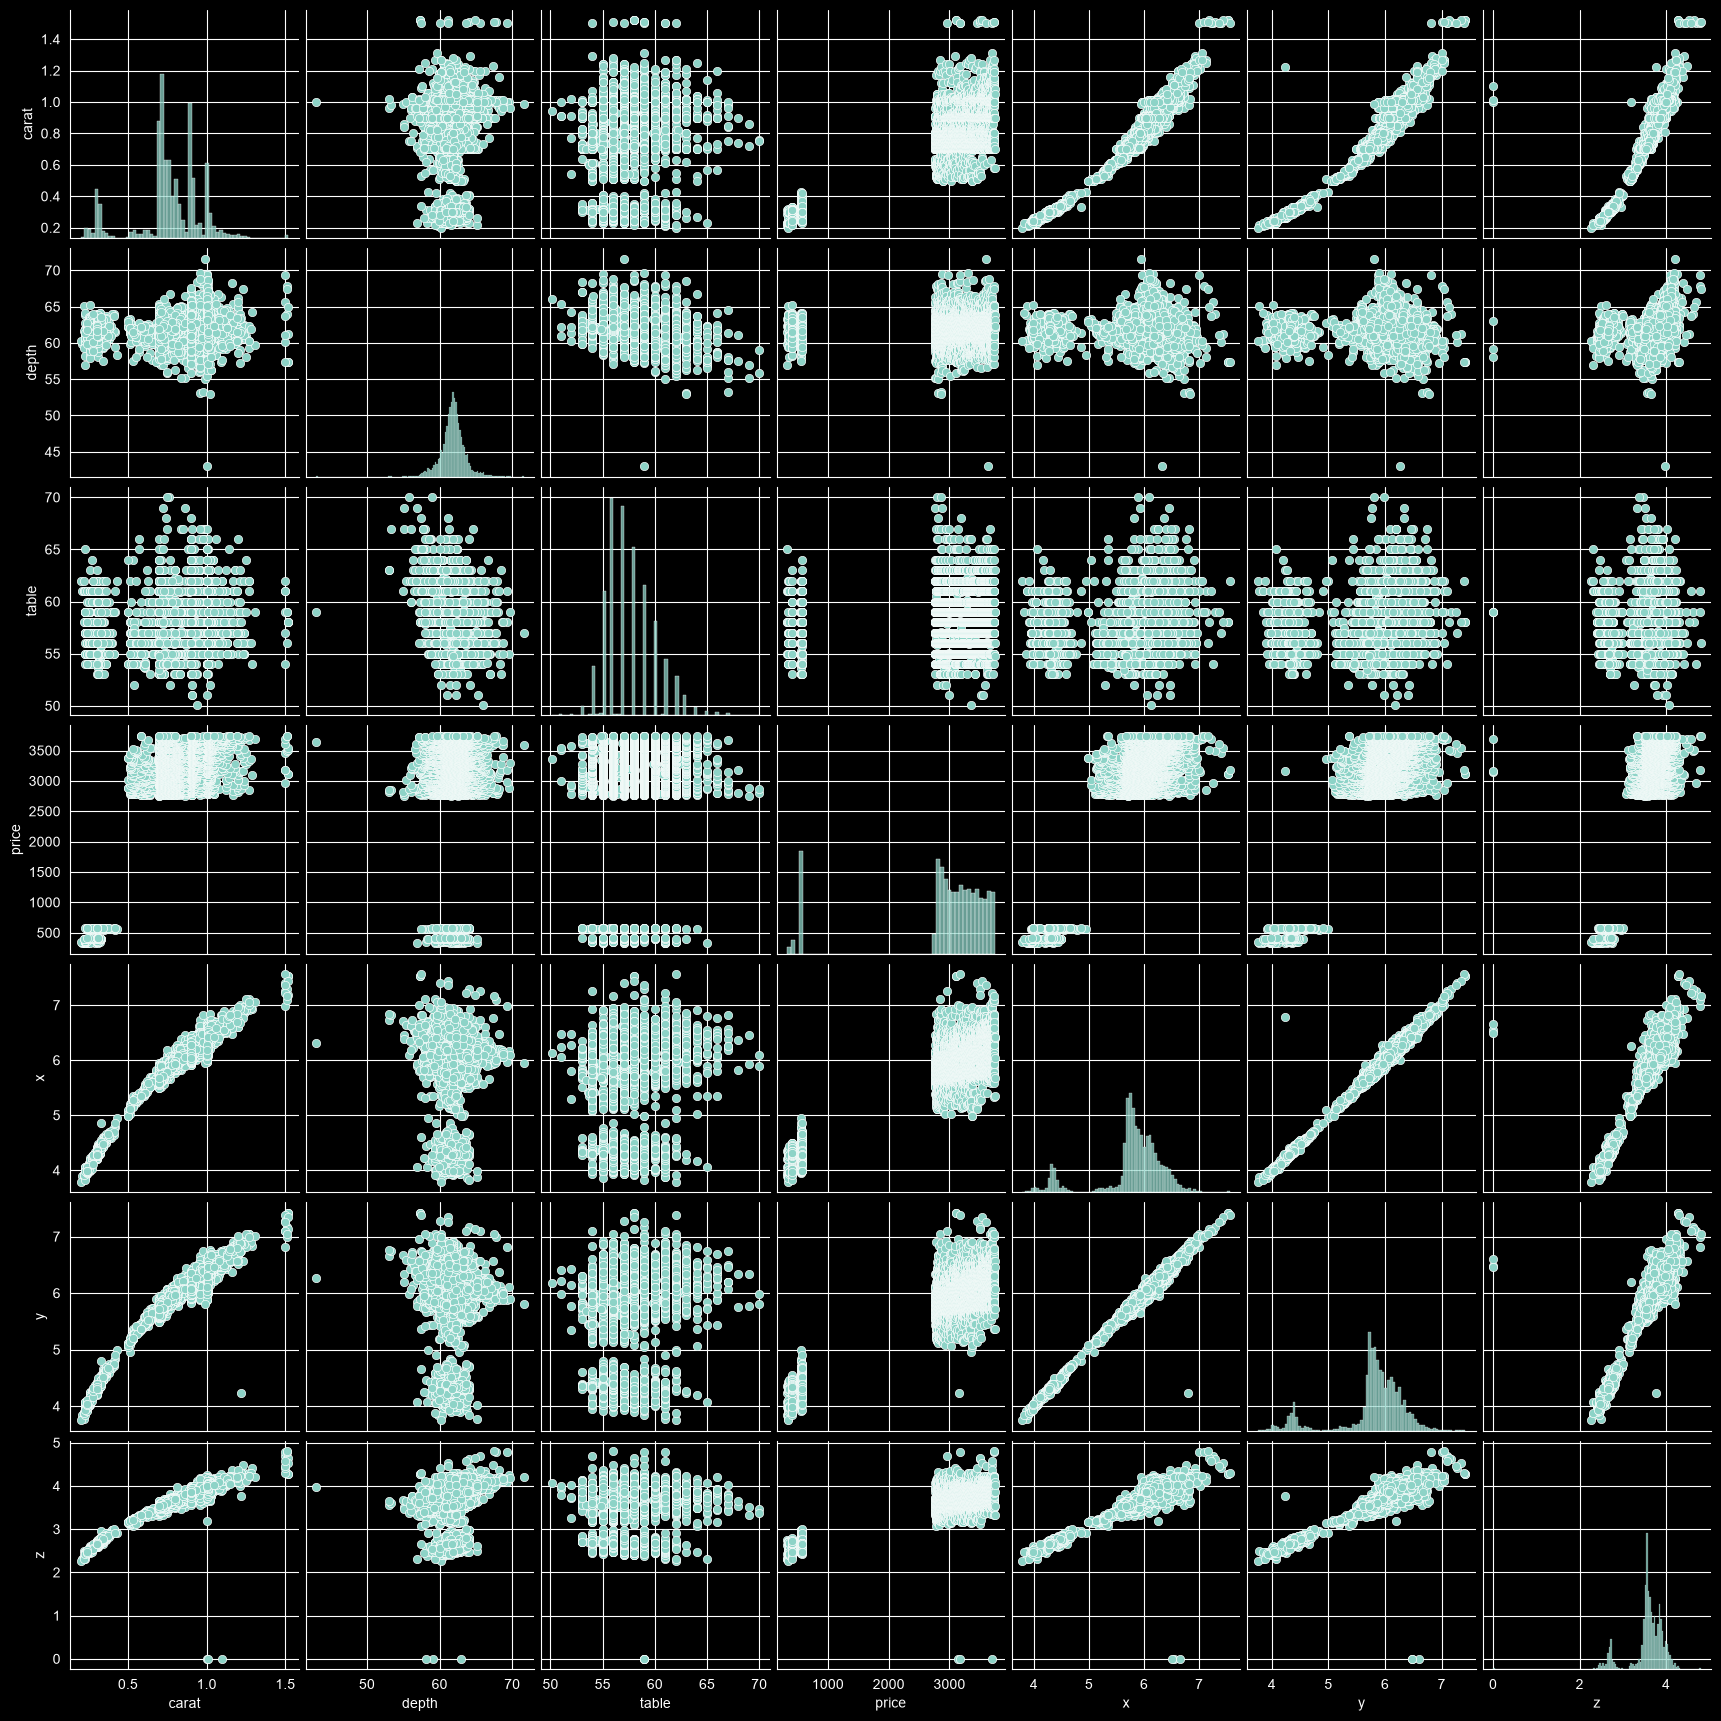

In [7]:
sns.pairplot(data);

### Диаграмма рассеяния — Scatter Plot

<Axes: xlabel='x', ylabel='carat'>

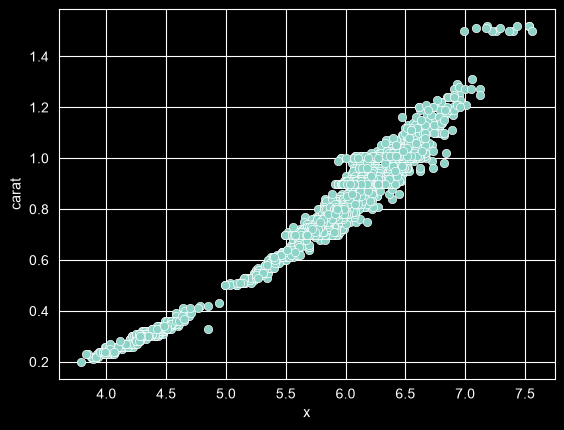

In [8]:
sns.scatterplot(data=data, x='x', y='carat')

<Axes: xlabel='x', ylabel='carat'>

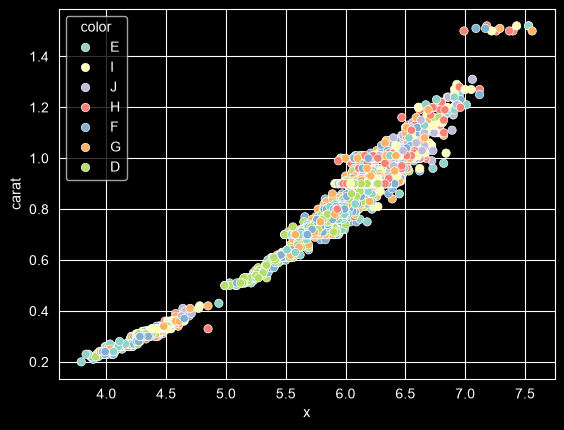

In [9]:
sns.scatterplot(data=data, x='x', y='carat', hue='color')

### Гистограмма

<Axes: xlabel='depth', ylabel='Count'>

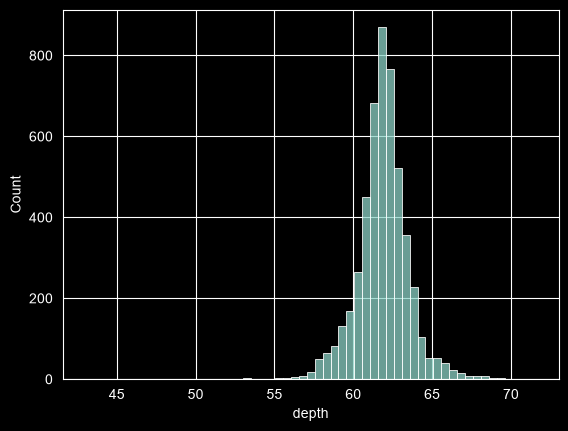

In [10]:
sns.histplot(data.depth, binwidth=0.5)

In [11]:
data.depth.min(), data.depth.max()

(np.float64(43.0), np.float64(71.6))

In [12]:
data.depth.mean()

np.float64(61.855140000000006)

In [13]:
from scipy.stats import shapiro

In [14]:
shapiro(data.depth)

ShapiroResult(statistic=np.float64(0.9541589189839587), pvalue=np.float64(5.441833513564145e-37))

Поскольку p-значение меньше 0.05, мы отвергаем нулевую гипотезу теста Шапиро-Уилка.

Это означает, что у нас есть достаточно доказательств, чтобы сказать, что данные выборки не получены из нормального распределения.



### Ящик с усами — Boxplot

<Axes: xlabel='carat'>

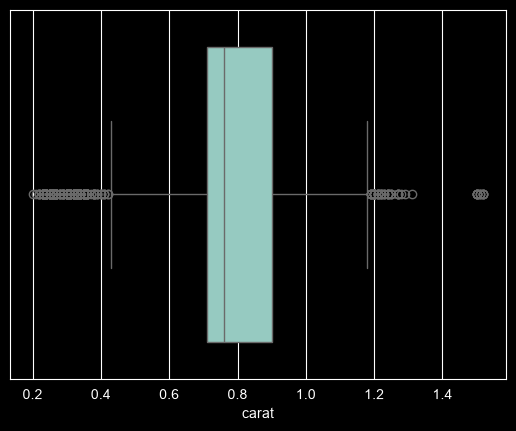

In [15]:
sns.boxplot(data=data, x='carat')

<Axes: xlabel='carat', ylabel='cut'>

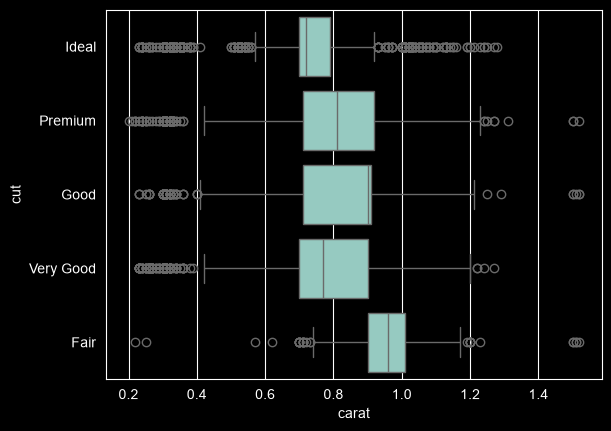

In [16]:
sns.boxplot(data=data, x='carat', y='cut')

### Столбчатая диаграмма — Barplot

In [17]:
data.price.mean()

np.float64(2927.6004)

<Axes: xlabel='price', ylabel='cut'>

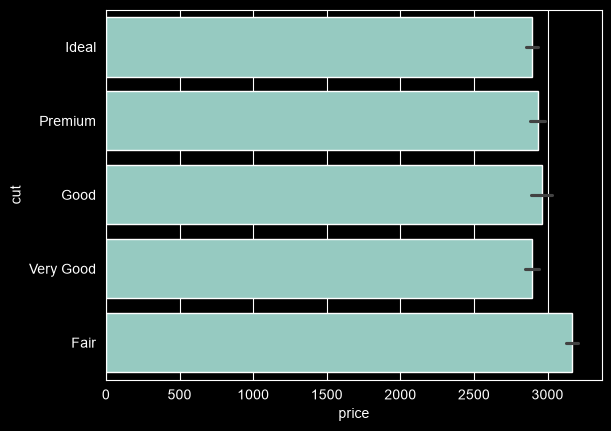

In [18]:
sns.barplot(data=data, x='price', y = 'cut')

<Axes: xlabel='cut', ylabel='count'>

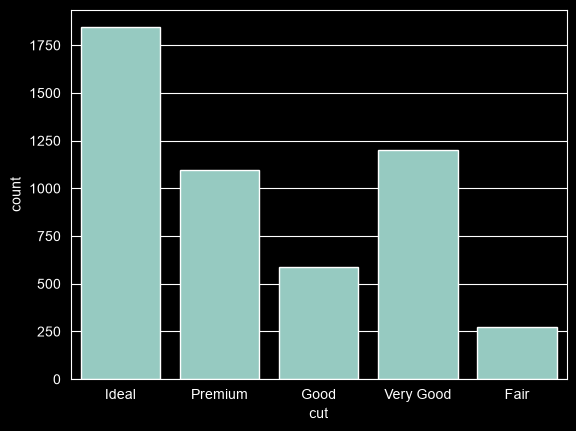

In [19]:
sns.countplot(data=data, x='cut')

### Тепловая карта – Heatmap

In [20]:
number = ['price', 'depth', 'table', 'x', 'y', 'z', 'carat']
data[number].corr()

,price,depth,table,x,y,z,carat
price,1.000000,0.021819,0.088999,0.876479,0.886886,0.839612,0.816999
depth,0.021819,1.000000,-0.251419,-0.023933,-0.033760,0.229995,0.108410
table,0.088999,-0.251419,1.000000,0.191402,0.176857,0.106500,0.205808
x,0.876479,-0.023933,0.191402,1.000000,0.994109,0.931451,0.976352
y,0.886886,-0.033760,0.176857,0.994109,1.000000,0.928559,0.968055
z,0.839612,0.229995,0.106500,0.931451,0.928559,1.000000,0.942128
carat,0.816999,0.108410,0.205808,0.976352,0.968055,0.942128,1.000000


<Axes: >

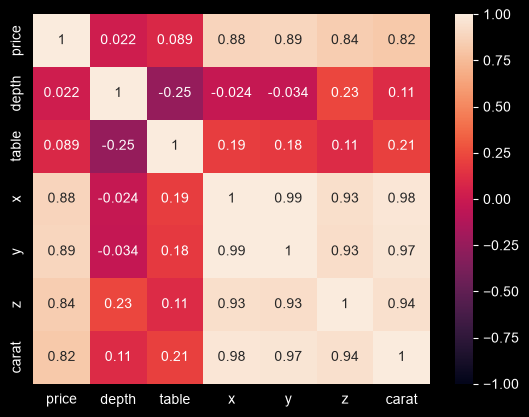

In [30]:
sns.heatmap(data[number].corr(), vmin=-1, vmax=1, annot=True)

## Matplotlib

### Диаграмма рассеяния — Scatter Plot

<Axes: xlabel='x', ylabel='carat'>

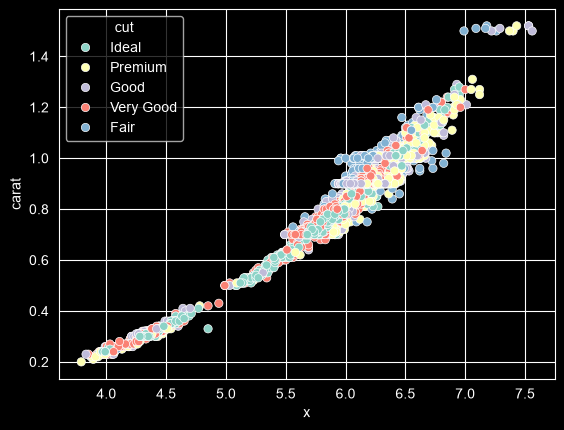

In [21]:
sns.scatterplot(data=data, x='x', y='carat', hue='cut')

Text(0, 0.5, 'carat')

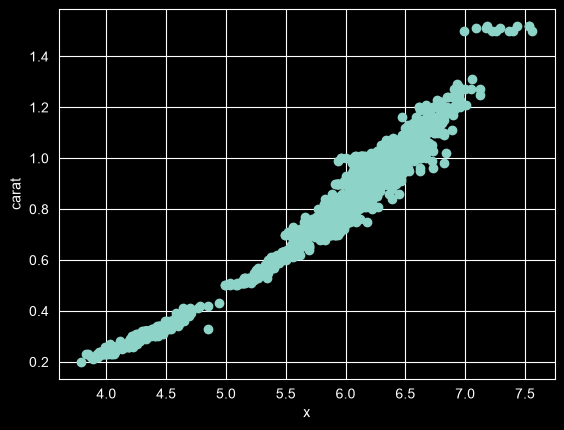

In [22]:
plt.scatter(data.x, data.carat)

plt.xlabel('x')
plt.ylabel('carat')

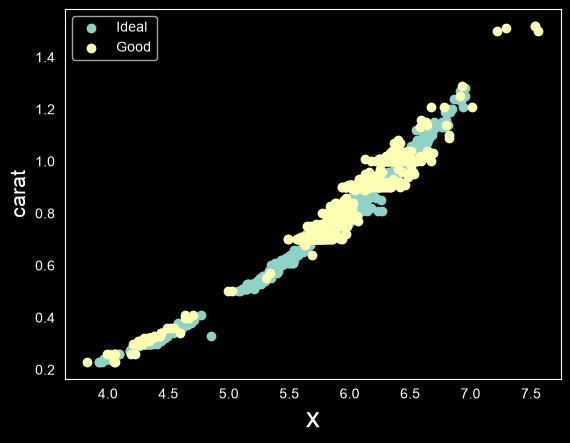

In [23]:
plt.scatter(data[data.cut == 'Ideal'].x, data[data.cut == 'Ideal'].carat, label='Ideal')
plt.scatter(data[data.cut == 'Good'].x, data[data.cut == 'Good'].carat, label='Good')

plt.xlabel('x', size=20)
plt.ylabel('carat', size=15)
plt.legend()

plt.grid()

### Круговая диаграмма

In [24]:
data.cut.value_counts()

cut
Ideal        1845
Very Good    1199
Premium      1094
Good          587
Fair          275
Name: count, dtype: int64

In [25]:
data.cut.unique()

<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

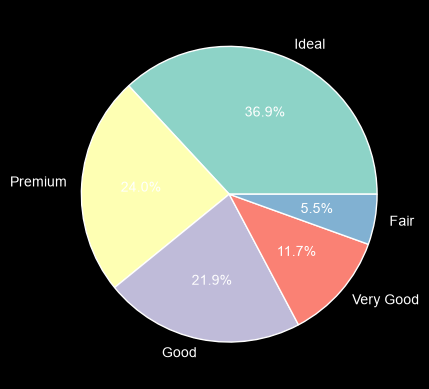

In [26]:
plt.pie(data.cut.value_counts(), labels=data.cut.unique(), autopct='%1.1f%%');

## Plotly

In [27]:
px.histogram(data.depth, color=data.cut)

In [28]:
px.box(data, x='carat')

In [29]:
px.box(data, x='carat', color='cut')

### Итоги:

1. Хорошая визуализация – понятная визуализация для людей, не сильно знакомых с данными. Она содержит:
    - оси и шкалы;
    - заголовок и подписи данных;
    - визуальную кодировку.

2. Различные типы графиков решают разные задачи:

  <b>Гистограммы:</b>
  - Используются для отображения распределения данных.
  - Помогают выявить основные пики, выбросы и скошенность данных.
  - Позволяют оценить центральные тенденции и разброс данных.
    
  <b>Диаграммы рассеяния (Scatter Plots):</b>
  - Используются для исследования взаимосвязи между двумя числовыми переменными.
  - Позволяют выявить корреляции, выбросы и группировки данных.
  - Подходят для выявления зависимостей и трендов.

  <b>Ящики с усами (Boxplots):</b>
  - Используются для отображения распределения данных и выявления выбросов.
  - Позволяют оценить медиану, межквартильный размах и наличие выбросов в данных.
  - Подходят для сравнения распределений разных категорий.

  <b>Тепловые карты (Heatmaps):</b>
  - Используются для визуализации матриц корреляции или данных сеток/таблиц.
  - Позволяют выявить паттерны и зависимости в данных.
  - Часто используются для исследования корреляции между признаками в больших наборах данных.

  <b>Круговые диаграммы (Pie Charts):</b>
  - Используются для отображения долей категорий в целом.
  - Подходят для представления процентного соотношения категорий.
  - Могут быть полезными для сравнения частей в целом.

  <b>Графики баров (Bar Charts):</b>
  - Используются для сравнения количественных данных между категориями.
  - Подходят для отображения изменений во времени или между разными группами.
